Prédiction de la probabilité de "stress hydrique", le stress hydrique étant considéré ici comme se référant à l'appartenance à la classe "iC-APEX < 0.5", et de l'incertitude associée.

Covariables attendues :
- Raster d'altitude
- Raster de réserve utile (catégoriel)
- Raster de CWB semaine par semaine (le modèle chosira en fonction de la semaine ciblée)
- Données SAFRAN en csv

Variable cible :
- Valeur continue 0 < p < 1 : probabilité de présence pour chaque classe (iC-apex < 0.5 et iC-apex > 0.5)

Le modèle utilise la loss DeepMaxent, AUC-ROC et Accuracy sont calculées comme métriques d'évaluation. Le split est fait par blocs spatiaux et utilise la méthode Leave-One-Block-Out. L'incertitude associée est prédite parallèlement avec la méthode MC-Dropout. Optuna calcule les meilleurs hyperparamètres avant entraînement.

# 0. IMPORTS

In [1]:
# Ignorer les avertissements
import warnings
warnings.filterwarnings('ignore')

# Libraries de base
import numpy as np
import pandas as pd
import os
import re
import ast
import glob
from tqdm import tqdm
from datetime import datetime, timedelta
import json
import pickle
from pathlib import Path

# Libraries géospatiales
import rasterio
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd
from shapely.geometry import Point

# Machine Learning
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.neighbors import BallTree
from sklearn.model_selection import KFold
import torch.optim as optim
import copy

# Working directory
import sys
sys.path.append("C:/Users/juillact/Documents/deep-ApexVigne")

# Modules deep learning personnalisés
from src.model import (
    mlp_model,
    predict_with_uncertainty
)
from src.losses import deepmaxent_loss

# Imports additionnels pour l'entraînement et l'évaluation du modèle
import torch.optim as optim
from scipy.stats import kendalltau
import copy

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

# Configuration de l'environnement pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


# 1. CHARGEMENT DES DONNEES APEX-VIGNE

## 1.1 Charger le jeu de données Apex-vigne

In [2]:
df = pd.read_csv('data/data_irrig_cep.csv', encoding='latin1', low_memory=False)
print(f"{df.shape[0]:,} observations × {df.shape[1]} columns")


46,403 observations × 22 columns


## 1.2 Choix du type de modèle et de la date

In [3]:
MODEL_TAG = "degrade"
date_debut_str = "2025-07-21"

## 1.3 Filtre par date

In [4]:
date_debut = pd.to_datetime(date_debut_str)
date_fin = date_debut + pd.Timedelta(days=6)
date_fin_str = date_fin.strftime("%Y-%m-%d")

# Filtrage temporel
df['date_session'] = pd.to_datetime(df['date_session'], errors='coerce')
df_filtered = df[(df['date_session'] >= date_debut_str) & (df['date_session'] <= date_fin_str)]

print(f"{date_debut_str} → {date_fin_str}")
print(f"Observations sélectionnées : {len(df_filtered):,}/{len(df):,} ({len(df_filtered)/len(df)*100:.2f}%)")

2025-07-21 → 2025-07-27
Observations sélectionnées : 1,137/46,403 (2.45%)


## 1.4 Conversion en objet spatial

In [5]:
# Conversion en objet spatial
df_filtered_sf = (df_filtered
    .assign(
        longitude = pd.to_numeric(df['longitude'].replace("NULL", pd.NA), errors='coerce'),
        latitude  = pd.to_numeric(df['latitude'].replace("NULL", pd.NA),  errors='coerce')
    )
    .dropna(subset=['longitude', 'latitude'])
    .pipe(lambda d: gpd.GeoDataFrame(
        d,
        geometry=gpd.points_from_xy(d['longitude'], d['latitude']),
        crs="EPSG:4326"
    ))
)

## 1.5 Filtrage spatial

In [6]:
# Charger la zone d'étude
study_zone = gpd.read_file("data/study_zone_viti.gpkg")
study_zone_wgs = study_zone.to_crs("EPSG:4326")

# Projection des observations dans le même système de coordonnées que la zone d'étude
df_filtered_sf_proj = df_filtered_sf.to_crs(study_zone.crs)

# Jointure pour filtrer les observations dans la zone d'étude
df_zone = gpd.sjoin(df_filtered_sf_proj, study_zone, how="inner", predicate="within").copy()

print(f"{len(df_zone):,}/{len(df_filtered_sf_proj):,} observations sélectionnées")

# Chargement des départements de la zone d'étude pour l'arrière-plan de la carte
study_zone_bg = gpd.read_file("data/study_zone.gpkg")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")

751/1,136 observations sélectionnées


## 1.6 Ajouts supplémentaires

### 1.6.1 Identifiant de maille SAFRAN

In [7]:
# Conversion des coordonnées SAFRAN en GeoDataFrame
coords_safran = pd.read_csv("data/cov/coordonnees_mailles_safran.csv", sep=";")
coords_safran_gdf = gpd.GeoDataFrame(
    coords_safran,
    geometry=gpd.points_from_xy(coords_safran["longitude"], coords_safran["latitude"]),
    crs="EPSG:4326"
).to_crs(study_zone.crs)

# Pour chaque observation, on cherche la maille SAFRAN la plus proche et on ajoute l'identifiant 'cell' correspondant
def find_nearest_cell(geom, safran_gdf):
    distances = safran_gdf.geometry.distance(geom)
    return safran_gdf.iloc[distances.idxmin()]["cell"]

df_zone["cell"] = df_zone.geometry.apply(
    lambda g: find_nearest_cell(g, coords_safran_gdf)
)

### 1.6.2 Indice de croissance des apex (iC-Apex)

In [8]:
# Calcul de l'iC-APEX et ajout de la colonne correspondante
df_zone['ic_apex'] = (df_zone['apex0'] + 0.5 * df_zone['apex1']) / (
    df_zone['apex0'] + df_zone['apex1'] + df_zone['apex2']
)

# 2. CHARGEMENT DE LA GRILLE DE LA ZONE D'ETUDE

## 2.1 Chargement de la grille

In [9]:
grid = gpd.read_file("data/study_zone_viti_grid.gpkg")
grid_proj = grid.to_crs("EPSG:2154")
print(f"{grid_proj.shape[0]:,} cellules")

36,377 cellules


## 2.2 Ajout de la coordonnée de cellule SAFRAN la plus proche

In [10]:
# Coordonnées des centroïdes de la grille
grid_coords = np.array([
    (geom.centroid.x, geom.centroid.y) for geom in grid_proj.geometry
])

# Coordonnées des points SAFRAN
safran_coords = np.array([
    (geom.x, geom.y) for geom in coords_safran_gdf.geometry
])

# Recherche du point SAFRAN le plus proche pour chaque cellule
tree = BallTree(safran_coords, metric="euclidean")
indices = tree.query(grid_coords, k=1, return_distance=False).flatten()

grid_proj = grid_proj.copy()
grid_proj["cell"] = coords_safran_gdf.iloc[indices]["cell"].values

# 3. CHARGEMENT DES COVARIABLES

## 3.1 Chargement des fichiers rasters

In [11]:
# Covariables topographiques et réserve utile
subfolders = ['alt', 'pente', 'exp', 'ru']
raster_files = []
for sub in subfolders:
    files = sorted(glob.glob(f'data/cov/rasters/{sub}/*.tif'))
    raster_files.extend(files)

# Précipitations cumulées basé sur (date_debut - 1)
date_pluvio = date_debut - timedelta(days=1)
date_pluvio_str = date_pluvio.strftime("%Y-%m-%d")
pluvio_raster_path = f"data/cov/rasters/pluvio/PLUIE_CUM_1km_{date_pluvio_str}.tif"
pluvio_file = glob.glob(pluvio_raster_path)
if not pluvio_file:
    print(f"Le raster de pluie cumulée pour la date {date_pluvio_str} est introuvable à l'adresse {pluvio_raster_path}")
else:
    raster_files.extend(pluvio_file)

# Affichage des informations sur les rasters
for f in raster_files:
    with rasterio.open(f) as src:
        res = abs(src.transform[0])
        print(f"   {f}")
        print(f"      Dimensions : {src.width} × {src.height} pixels")
        print(f"      Résolution : {res:.0f} m\n")

Le raster de pluie cumulée pour la date 2025-07-20 est introuvable à l'adresse data/cov/rasters/pluvio/PLUIE_CUM_1km_2025-07-20.tif
   data/cov/rasters/ru/ru_raster.tif
      Dimensions : 425 × 336 pixels
      Résolution : 1000 m



## 3.2 Chargement des fichiers CSV (données SAFRAN)

In [12]:
# Chargement unique du CSV SAFRAN
year = pd.to_datetime(date_debut_str).year
df_safran = pd.read_csv(f"data/cov/cov_siclima_{year}.csv", engine='python')
df_safran = df_safran.set_index("cell")  # indexation par cell pour accès rapide

# Liste complète, dans le même ordre que le vecteur brut du CSV
FULL_SAFRAN_NAMES = ["dli_q", "t_q", "co2", "drainc_q", "pe_q", "preliq_q",
                      "wg_racine_q", "tsup_h_q", "tinf_h_q", "etp_q",
                      "evap_q", "hu_q", "runc_q", "swi_q", "q_q"]

# Définition des variables à exclure selon le modèle choisi
if MODEL_TAG == "classique":
    EXCLUDED_NAMES = ["co2", "pe_q", "preliq_q", "etppm"]  # non utilisées dans tous les cas
elif MODEL_TAG == "degrade":
    EXCLUDED_NAMES = [name for name in FULL_SAFRAN_NAMES if name not in ("t_q", "tsup_h_q", "tinf_h_q")]

ALL_SAFRAN_NAMES = FULL_SAFRAN_NAMES  # toujours la liste complète : les indices doivent matcher le CSV brut
KEEP_INDICES = [i for i, name in enumerate(ALL_SAFRAN_NAMES) if name not in EXCLUDED_NAMES]
KEEP_NAMES   = [name for name in ALL_SAFRAN_NAMES if name not in EXCLUDED_NAMES]
N_COV_SAFRAN = len(KEEP_INDICES)

# Sécurité et extraction des covariables SAFRAN pour chaque cellule et date d'observation
def load_SAFRAN_vector(cell: int, date_obs: str) -> np.ndarray:
    if cell not in df_safran.index:
        return np.full(N_COV_SAFRAN, np.nan, dtype=np.float32)
    if date_obs not in df_safran.columns:
        return np.full(N_COV_SAFRAN, np.nan, dtype=np.float32)
    valeur = df_safran.loc[cell, date_obs]
    if isinstance(valeur, str):
        valeur = ast.literal_eval(valeur)
    valeur = np.array(valeur, dtype=np.float32)
    return valeur[KEEP_INDICES]

SAFRAN_values = np.array([
    load_SAFRAN_vector(cell=row["cell"], date_obs=date_debut_str)
    for _, row in grid_proj.iterrows()
], dtype=np.float32)

print("Données SAFRAN extraites avec succès pour la semaine du :", date_debut_str)
print(f"   Covariables SAFRAN retenues ({N_COV_SAFRAN}) : {KEEP_NAMES}")

Données SAFRAN extraites avec succès pour la semaine du : 2025-07-21
   Covariables SAFRAN retenues (3) : ['t_q', 'tsup_h_q', 'tinf_h_q']


# 4. PREPARATION DES DONNEES D'ENTRAINEMENT

## 4.1 Ajout des données raster au tenseur X

In [13]:
num_cells = len(grid_proj)
num_variables = len(raster_files)

# Tenseur X des covariables
X_tensor = torch.zeros((num_cells, num_variables), dtype=torch.float32)

print("Extraction des valeurs des covariables raster...")
for var_idx, filepath in enumerate(raster_files):
    with rasterio.open(filepath) as src:
        nodata = src.nodata
        values = np.array([val[0] for val in src.sample(grid_coords)], dtype=np.float32)
        if nodata is not None:
            values[values == nodata] = np.nan
        X_tensor[:, var_idx] = torch.tensor(values, dtype=torch.float32)

print(f"Tenseur X créé avec succès : {X_tensor.shape[0]:,} cellules × {X_tensor.shape[1]:,} variables")

Extraction des valeurs des covariables raster...
Tenseur X créé avec succès : 36,377 cellules × 1 variables


## 4.2 Ajout des données CSV (SAFRAN) au tenseur X

In [14]:
X_SAFRAN = torch.tensor(SAFRAN_values, dtype=torch.float32)
X_tensor = torch.cat([X_tensor, X_SAFRAN], dim=1)
num_variables = X_tensor.shape[1]
print(f"Tenseur X complété avec succès : {X_tensor.shape[0]:,} cellules × {X_tensor.shape[1]:,} variables")

Tenseur X complété avec succès : 36,377 cellules × 4 variables


## 4.3 Encodage one-hot des covariables catégorielles

In [15]:
# Index de la colonne RU dans all_raster_files
ru_idx = next(i for i, f in enumerate(raster_files) if 'ru' in f.lower())

# Valeurs RU brutes
ru_values = X_tensor[:, ru_idx].numpy()

# Classes attendues (9 = non-sol traité séparément)
ru_classes = [1, 2, 3, 4, 5, 9]

# One-hot encoding
ru_onehot = np.zeros((num_cells, len(ru_classes)), dtype=np.float32)
for j, cls in enumerate(ru_classes):
    ru_onehot[:, j] = (ru_values == cls).astype(np.float32)

# Remplacement de la colonne RU par les colonnes one-hot
X_np = X_tensor.numpy() # on repasse en tableau NumPy pour le découpage et la concaténation
X_np_without_ru = np.delete(X_np, ru_idx, axis=1)
X_tensor = torch.tensor(
    np.concatenate([X_np_without_ru, ru_onehot], axis=1),
    dtype=torch.float32
)

# Mise à jour du nombre de variables
num_variables = X_tensor.shape[1]

print(f"Encodage en one-hot de {len(ru_classes)} classes réalisé avec succès. \nTenseur X mis à jour : {X_tensor.shape[0]:,} cellules × {X_tensor.shape[1]:,} variables")

Encodage en one-hot de 6 classes réalisé avec succès. 
Tenseur X mis à jour : 36,377 cellules × 9 variables


## 4.4 Création du tenseur Y des données Apex-Vigne

In [16]:
# Seuil de binarisation iC-APEX
IC_APEX_THRESHOLD = 0.5  # >= seuil → classe de non-stress hydrique, < seuil → classe de stress hydrique

In [17]:
# Indexation des cellules de la grille
grid_idx  = grid_proj.copy()
grid_idx['cell_idx'] = range(num_cells)

# Associe chaque point d'observation au numéro de la case de la grille qui le contient
joined = gpd.sjoin(df_zone[['ic_apex', 'geometry']],
                   grid_idx[['cell_idx', 'geometry']],
                   how='left', predicate='within')

# Comptage des deux classes par cellule
ic_counts = (
    joined.groupby('cell_idx')['ic_apex']
    .agg(
        n_nostress=lambda x: (x >= IC_APEX_THRESHOLD).sum(),
        n_stress =lambda x: (x <  IC_APEX_THRESHOLD).sum(),
        mean_ic_apex='mean'          # valeur moyenne pour l'affichage
    )
    .dropna()
)

# Tenseur Y — shape (num_cells, 2) : [n_nostress, n_stress]
y_tensor = torch.zeros((num_cells, 2), dtype=torch.float32)
y_tensor[ic_counts.index, 0] = torch.tensor(ic_counts['n_nostress'].values, dtype=torch.float32)
y_tensor[ic_counts.index, 1] = torch.tensor(ic_counts['n_stress'].values,  dtype=torch.float32)

# Masque pour les cellules observées uniquement (au moins 1 observation)
observed_mask = torch.zeros(num_cells, dtype=torch.bool)
observed_mask[ic_counts.index] = True

# Masque pour exclure les non-sols (RU == 9)
nonsoil_mask  = torch.tensor(ru_values == 9)
observed_mask = observed_mask & ~nonsoil_mask

# Stats sur les cellules observées
n_nostress_total = y_tensor[observed_mask, 0].sum().item()
n_stress_total  = y_tensor[observed_mask, 1].sum().item()
n_obs_total      = n_nostress_total + n_stress_total

print(f"\nTenseur Y créé avec succès : {y_tensor.shape[0]:,} cellules × {y_tensor.shape[1]} classes")
print(f"   Seuil iC-APEX                     : {IC_APEX_THRESHOLD}")
print(f"   Cellules observées                : {observed_mask.sum().item():,}")
print(f"   Observations totales              : {int(n_obs_total):,}")
print(f"   iC-APEX >= {IC_APEX_THRESHOLD}             : {int(n_nostress_total):,}")
print(f"   iC-APEX < {IC_APEX_THRESHOLD}             : {int(n_stress_total):,}")
print(f"   Ratio iC-APEX >= {IC_APEX_THRESHOLD}                   : {n_nostress_total / n_obs_total * 100:.1f}%")
print(f"   Cellules non-sol exclues          : {nonsoil_mask.sum().item():,}")
print(f"   Cellules masquées (non observées) : {(~observed_mask).sum().item():,} / {num_cells:,}")


Tenseur Y créé avec succès : 36,377 cellules × 2 classes
   Seuil iC-APEX                     : 0.5
   Cellules observées                : 229
   Observations totales              : 741
   iC-APEX >= 0.5             : 391
   iC-APEX < 0.5             : 350
   Ratio iC-APEX >= 0.5                   : 52.8%
   Cellules non-sol exclues          : 367
   Cellules masquées (non observées) : 36,148 / 36,377


## 4.5 Préparation des données et des coordonnées pour la cartographie

In [18]:
# Sélection des cellules observées
obs_indices = np.where(observed_mask.numpy())[0]
X_obs = X_tensor[observed_mask]
y_obs = y_tensor[observed_mask]

# Coordonnées des centroïdes de la grille, reprojetées en WGS84 pour l'affichage
grid_wgs = grid_proj.to_crs("EPSG:4326")
coords_full = np.column_stack([grid_wgs.geometry.centroid.x, grid_wgs.geometry.centroid.y])

# Coordonnées et valeurs pour les cellules observées
obs_full = torch.zeros(num_cells, dtype=torch.float32)
obs_full[ic_counts.index] = torch.tensor(ic_counts['mean_ic_apex'].values, dtype=torch.float32)
obs_full = obs_full.numpy()
coords_obs  = coords_full[obs_indices]
ic_apex_obs = obs_full[obs_indices]

# 5. SPLIT ENTRAINEMENT/VALIDATION (RANDOM CROSS-VALIDATION)

## 5.1 Création des folds

In [19]:
N_SPLITS = 10
SEED = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

## 5.2 Construction des datasets par fold


In [20]:
x_trains, y_trains = [], []
x_vals,   y_vals   = [], []

for ind_train, ind_val in kf.split(X_obs):
    x_trains.append(X_obs[ind_train])
    y_trains.append(y_obs[ind_train])
    x_vals.append(X_obs[ind_val])
    y_vals.append(y_obs[ind_val])

## 5.3 Affichage des Folds

In [21]:
print(f"{N_SPLITS} folds créés :")
for i in range(N_SPLITS):
    n_train = len(x_trains[i])
    n_val   = len(x_vals[i])
    n_pos_t = y_trains[i].sum().item()
    n_pos_v = y_vals[i].sum().item()
    print(f"   Fold {i+1:2d} — Train : {n_train:3d} ({n_pos_t:.0f} non-stress) "
          f"| Val : {n_val:2d} ({n_pos_v:.0f} non-stress)")

10 folds créés :
   Fold  1 — Train : 206 (694 non-stress) | Val : 23 (47 non-stress)
   Fold  2 — Train : 206 (701 non-stress) | Val : 23 (40 non-stress)
   Fold  3 — Train : 206 (688 non-stress) | Val : 23 (53 non-stress)
   Fold  4 — Train : 206 (696 non-stress) | Val : 23 (45 non-stress)
   Fold  5 — Train : 206 (617 non-stress) | Val : 23 (124 non-stress)
   Fold  6 — Train : 206 (649 non-stress) | Val : 23 (92 non-stress)
   Fold  7 — Train : 206 (635 non-stress) | Val : 23 (106 non-stress)
   Fold  8 — Train : 206 (598 non-stress) | Val : 23 (143 non-stress)
   Fold  9 — Train : 206 (696 non-stress) | Val : 23 (45 non-stress)
   Fold 10 — Train : 207 (695 non-stress) | Val : 22 (46 non-stress)


# 6. CONFIGURATION DU MODELE

## 6.1 Configuration des hyperparamètres

In [22]:
class Args:
    def __init__(self):
        self.learning_rate = 0.03
        self.epoch         = 100
        self.hidden_nbr    = 2
        self.weight_decay  = 5e-2
        self.batch_size    = 32

args        = Args()
hidden_size = 64
dropout_p   = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 6.2 Paramètres structurels du réseau de neurones

In [23]:
# Nombre de colonnes continues (tout sauf les one-hot RU)
n_onehot     = len(ru_classes)
n_continuous = X_obs.shape[1] - n_onehot

input_size  = X_obs.shape[1]

## 6.3 Fonction d'entraînement

In [24]:
def train_model(X_train, y_train, X_val, y_val, args, hidden_size=128, device="cpu"):
    
    model     = mlp_model(X_train.shape[1], hidden_size, args.hidden_nbr, dropout_p).to(device)
    criterion = deepmaxent_loss()

    optimizer = optim.AdamW(model.parameters(),
                            lr=args.learning_rate,
                            weight_decay=args.weight_decay)

    X_train_dev = X_train.to(device)
    y_train_dev = y_train.to(device)
    X_val_dev   = X_val.to(device)
    y_val_dev   = y_val.to(device)

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    best_model_state = None

    print("Entraînement")

    for epoch in range(args.epoch):

        # Phase d'apprentissage
        model.train()
        optimizer.zero_grad()
        outputs    = model(X_train_dev)
        loss       = criterion(outputs, y_train_dev)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Phase de validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_dev)
            val_loss    = criterion(val_outputs, y_val_dev).item()
        val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:3d} | Train: {loss.item():.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)

    # AUC sur le meilleur modèle
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_dev)
        val_probs  = torch.softmax(val_logits, dim=0)[:, 0].cpu().numpy()

    y_val_np     = (y_val[:, 0] / (y_val[:, 0] + y_val[:, 1]).clamp(min=1e-8)).numpy()
    y_val_binary = (y_val_np >= 0.5).astype(int)

    if len(np.unique(y_val_binary)) < 2:
        print("Le set de validation ne contient qu'une seule classe : AUC indéfinie.\n")
        return None

    val_auc = roc_auc_score(y_val_binary, val_probs)
    val_kendall = kendalltau(y_val_binary, val_probs).statistic
    
    print(f"Meilleur loss de validation : {best_val_loss:.4f} | AUC : {val_auc:.4f} | Kendall tau : {val_kendall:.4f}\n")

    return {
        "model"        : model,
        "train_losses" : train_losses,
        "val_losses"   : val_losses,
        "best_val_loss": best_val_loss,
        "val_auc"      : val_auc,
        "val_kendall"  : val_kendall,
        "val_preds"    : val_probs,
        "val_trues"    : y_val_binary
    }

# 7. ENTRAINEMENT DU MODELE

In [25]:
all_results = []

for fold_idx in range(N_SPLITS):
    print(f"FOLD {fold_idx + 1} / {N_SPLITS}")

    # Preprocessing du fold
    X_train_raw = x_trains[fold_idx]
    X_val_raw   = x_vals[fold_idx]
    y_train_f   = y_trains[fold_idx]
    y_val_f     = y_vals[fold_idx]

    # Suppression NaN
    train_nan_mask = torch.isnan(X_train_raw).any(dim=1)
    val_nan_mask   = torch.isnan(X_val_raw).any(dim=1)
    
    X_train_clean  = X_train_raw[~train_nan_mask]
    y_train_clean  = y_train_f[~train_nan_mask]
    X_val_clean    = X_val_raw[~val_nan_mask]
    y_val_clean    = y_val_f[~val_nan_mask]

    # Vérifie si le jeu de validation ou d'entraînement est vide après nettoyage
    if len(X_val_clean) == 0:
        print(f"Fold {fold_idx + 1} ignoré : aucune donnée de validation valide après suppression des NaNs.")
        continue
    if len(X_train_clean) == 0:
        print(f"Fold {fold_idx + 1} ignoré : aucune donnée d'entraînement valide après suppression des NaNs.")
        continue

    # Normalisation (fit sur train uniquement)
    scaler_fold = StandardScaler()
    X_train_cont_scaled = scaler_fold.fit_transform(X_train_clean[:, :n_continuous].numpy())
    X_val_cont_scaled   = scaler_fold.transform(X_val_clean[:, :n_continuous].numpy())

    X_train_tensor_f = torch.tensor(
        np.concatenate([X_train_cont_scaled, X_train_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    # Entraînement
    fold_results = train_model(
        X_train     = X_train_tensor_f,
        y_train     = y_train_clean,
        X_val       = X_val_tensor_f,
        y_val       = y_val_clean,
        args        = args,
        hidden_size = hidden_size,
        device      = device
    )

    if fold_results is not None:
        all_results.append({
            "fold"        : fold_idx + 1,
            "results"     : fold_results,
            "scaler"      : scaler_fold,
            "val_loss"    : fold_results["best_val_loss"],
            "val_auc"  : fold_results["val_auc"],
            "val_kendall" : fold_results["val_kendall"]
        })

FOLD 1 / 10
Entraînement
   Epoch   1 | Train: 0.0262 | Val: 0.1503
   Epoch  20 | Train: 0.0238 | Val: 0.1357
   Epoch  40 | Train: 0.0234 | Val: 0.1390
   Epoch  60 | Train: 0.0232 | Val: 0.1343
   Epoch  80 | Train: 0.0229 | Val: 0.1362
   Epoch 100 | Train: 0.0227 | Val: 0.1363
Meilleur loss de validation : 0.1316 | AUC : 0.6515 | Kendall tau : 0.2193

FOLD 2 / 10
Entraînement
   Epoch   1 | Train: 0.0269 | Val: 0.1412
   Epoch  20 | Train: 0.0237 | Val: 0.1482
   Epoch  40 | Train: 0.0235 | Val: 0.1470
   Epoch  60 | Train: 0.0232 | Val: 0.1520
   Epoch  80 | Train: 0.0232 | Val: 0.1480
   Epoch 100 | Train: 0.0233 | Val: 0.1501
Meilleur loss de validation : 0.1365 | AUC : 0.6083 | Kendall tau : 0.1504

FOLD 3 / 10
Entraînement
   Epoch   1 | Train: 0.0260 | Val: 0.1378
   Epoch  20 | Train: 0.0241 | Val: 0.1269
   Epoch  40 | Train: 0.0237 | Val: 0.1330
   Epoch  60 | Train: 0.0233 | Val: 0.1375
   Epoch  80 | Train: 0.0232 | Val: 0.1370
   Epoch 100 | Train: 0.0233 | Val: 0.1350

# 8. EVALUATION DU MODELE ET PREDICTION

## 8.1 Résumé de la validation croisée aléatoire avec métriques locales (par fold)

In [26]:
if len(all_results) > 0:
    val_losses = [r["val_loss"] for r in all_results]
    val_aucs   = [r["val_auc"]  for r in all_results]
    val_kendalls = [r["val_kendall"] for r in all_results]
    n_valid_folds = len(all_results)

    print(f"   Nombre de folds validés : {n_valid_folds} / {N_SPLITS}")

    print(f"   AUC par fold : {[f'{v:.4f}' for v in val_aucs]}")
    print(f"   AUC moyenne  : {np.mean(val_aucs):.4f} ± {np.std(val_aucs):.4f}")

    print(f"   Kendall tau par fold : {[f'{v:.4f}' for v in val_kendalls]}")
    print(f"   Kendall tau moyenne  : {np.mean(val_kendalls):.4f} ± {np.std(val_kendalls):.4f}")
    
    print(f"   Loss de validation par fold : {[f'{v:.4f}' for v in val_losses]}")
    print(f"   Loss de validation moyenne  : {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")
    
    # Identification du meilleur fold
    best_fold_idx = np.argmax(val_kendalls)
    best_fold = all_results[best_fold_idx]
    print(f"   Meilleur fold : Fold {best_fold['fold']} (Kendall tau = {best_fold['val_kendall']:.4f} | AUC = {best_fold['val_auc']:.4f} | Loss = {best_fold['val_loss']:.4f})")
else:
    print("Aucun fold n'a pu être entraîné avec succès.")

   Nombre de folds validés : 10 / 10
   AUC par fold : ['0.6515', '0.6083', '0.8431', '0.8137', '0.7679', '0.6349', '0.5357', '0.7768', '0.6429', '0.6562']
   AUC moyenne  : 0.6931 ± 0.0952
   Kendall tau par fold : ['0.2193', '0.1504', '0.4410', '0.4169', '0.3622', '0.1916', '0.0483', '0.3750', '0.1940', '0.2050']
   Kendall tau moyenne  : 0.2604 ± 0.1231
   Loss de validation par fold : ['0.1316', '0.1365', '0.1269', '0.1189', '0.1292', '0.1228', '0.1199', '0.1276', '0.1349', '0.1240']
   Loss de validation moyenne  : 0.1272 ± 0.0057
   Meilleur fold : Fold 3 (Kendall tau = 0.4410 | AUC = 0.8431 | Loss = 0.1269)


## 8.2 Affichage des courbes de loss

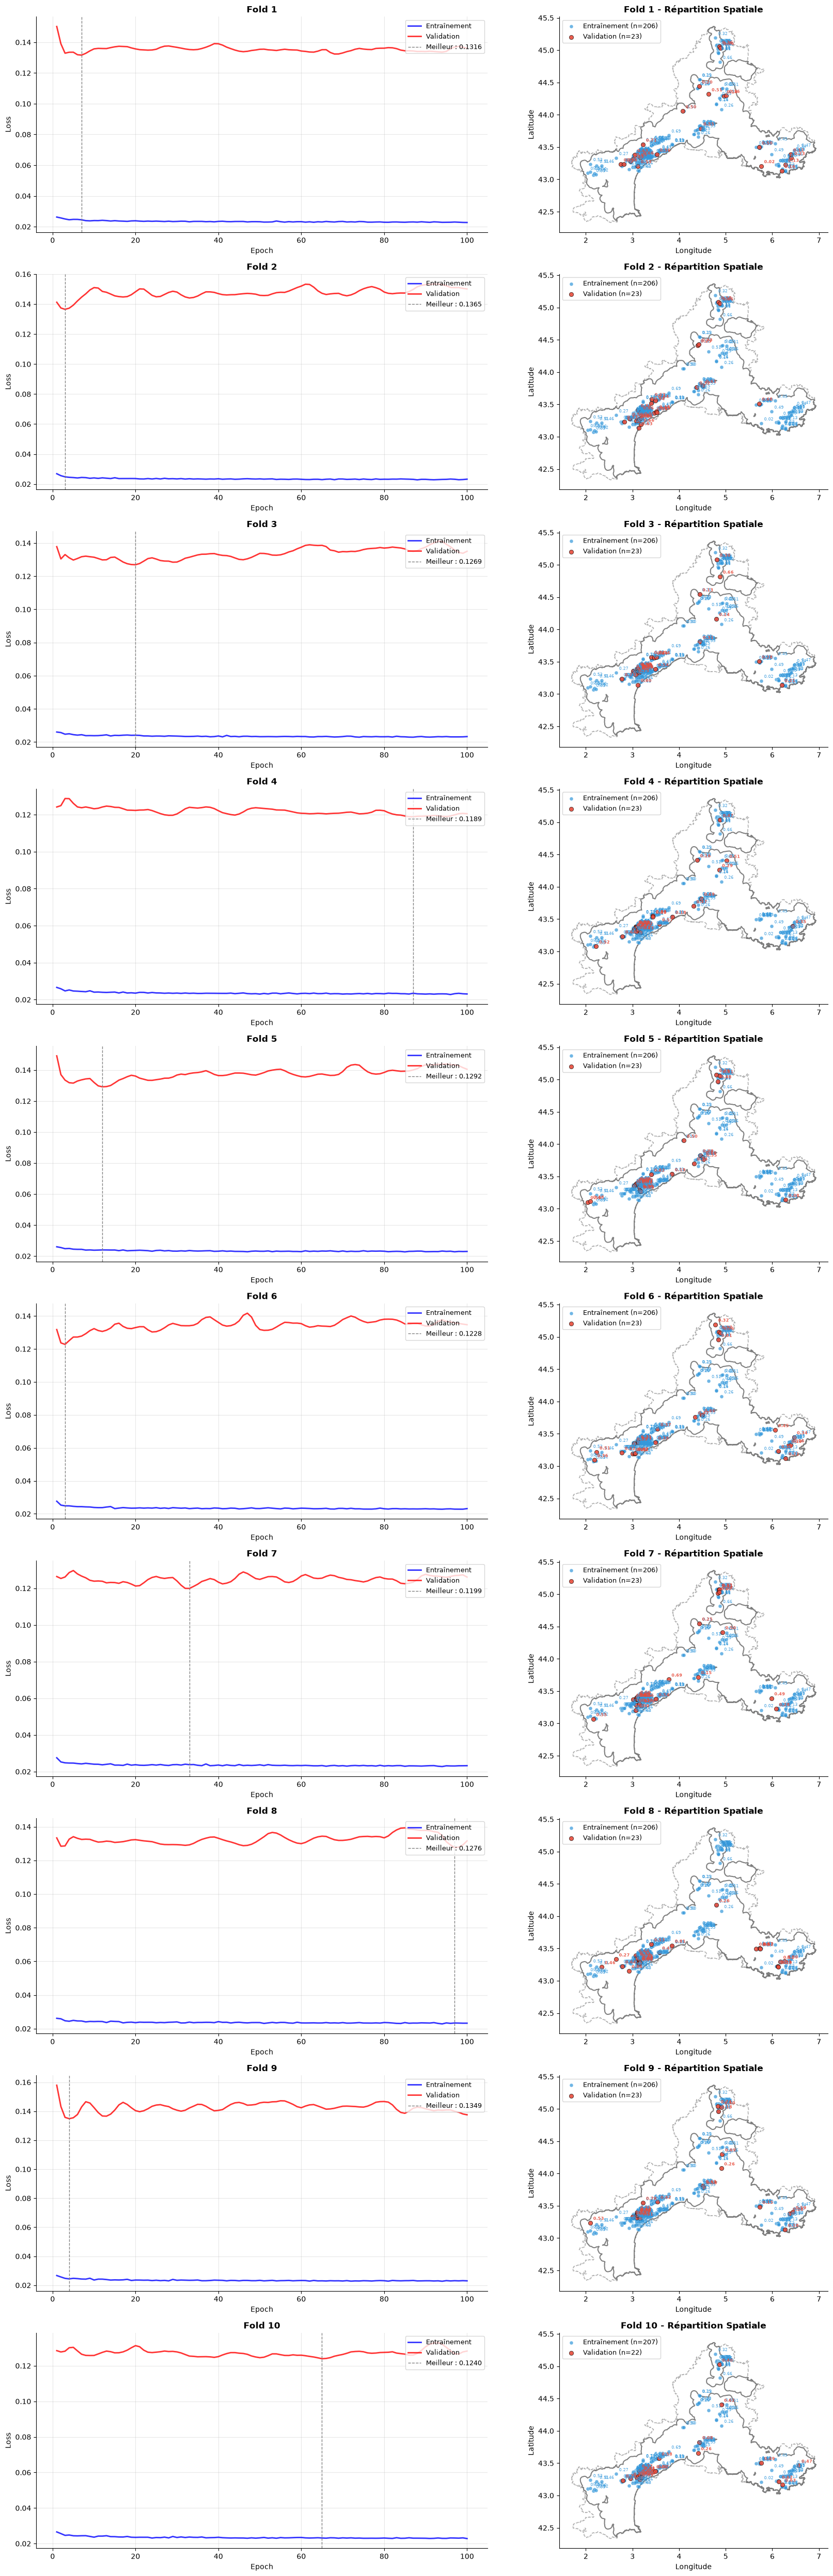

In [27]:
# n_valid_folds lignes, 2 colonnes (loss à gauche, carte à droite)
fig, axes = plt.subplots(n_valid_folds, 2, figsize=(18, 5 * n_valid_folds))

# si all_results ne contient qu'un seul fold (pour que axes reste une matrice 2D)
if n_valid_folds == 1:
    axes = np.expand_dims(axes, axis=0)

# recrée le générateur de split pour synchroniser les cartes avec les boucles de résultats
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
logo_viz = list(kf.split(X_obs))

# boucle sur les folds
for fold_idx, fold_data in enumerate(all_results):
    results_f = fold_data["results"]
    epochs    = range(1, len(results_f['train_losses']) + 1)
    
    # récupération des indices géographiques correspondants au fold courant
    ind_train, ind_val = logo_viz[fold_idx]
    train_coords = coords_obs[ind_train]
    val_coords   = coords_obs[ind_val]

    # courbe de Loss
    ax_loss = axes[fold_idx, 0]
    ax_loss.plot(epochs, results_f['train_losses'], 'b-', linewidth=2, label='Entraînement', alpha=0.8)
    ax_loss.plot(epochs, results_f['val_losses'],   'r-', linewidth=2, label='Validation',   alpha=0.8)
    ax_loss.axvline(x=results_f['val_losses'].index(results_f['best_val_loss']) + 1,
                    color='gray', linestyle='--', linewidth=1,
                    label=f"Meilleur : {results_f['best_val_loss']:.4f}")
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'Fold {fold_data["fold"]}', fontweight='bold')
    ax_loss.legend(fontsize=9, loc='upper right')
    ax_loss.grid(True, alpha=0.3)
    ax_loss.spines['top'].set_visible(False)
    ax_loss.spines['right'].set_visible(False)

    # carte des observations
    ax_map = axes[fold_idx, 1]
    
    # dessin du contour de la zone d'étude
    study_zone_wgs.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=1.5, alpha=0.5)
    study_zone_bg_wgs.plot(ax=ax_map, facecolor="none", edgecolor="grey", linewidth=1.2, linestyle="--", alpha=0.6)

    # affichage des points d'entraînement (Bleu)
    ax_map.scatter(train_coords[:, 0], train_coords[:, 1],
                   c='#3498db', s=25, alpha=0.7, 
                   label=f'Entraînement (n={len(train_coords)})',
                   edgecolor='white', linewidth=0.3)
    
    # affichage des points de validation (Rouge)
    ax_map.scatter(val_coords[:, 0], val_coords[:, 1],
                   c='#e74c3c', s=35, alpha=0.9, 
                   label=f'Validation (n={len(val_coords)})',
                   edgecolor='black', linewidth=0.5)

    # annotation des valeurs iC-apex à côté des points
    igapex_train = ic_apex_obs[ind_train]
    igapex_val   = ic_apex_obs[ind_val]

    for (x, y), val in zip(train_coords, igapex_train):
        ax_map.annotate(f"{val:.2f}", (x, y),
                         textcoords="offset points", xytext=(4, 4),
                         fontsize=6, color='#3498db', alpha=0.9)

    for (x, y), val in zip(val_coords, igapex_val):
        ax_map.annotate(f"{val:.2f}", (x, y),
                         textcoords="offset points", xytext=(4, 4),
                         fontsize=6, color='#e74c3c', alpha=0.9, fontweight='bold')
    
    # personnalisation de l'axe de la carte
    ax_map.set_title(f'Fold {fold_data["fold"]} - Répartition Spatiale', fontsize=12, fontweight='bold')
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')
    ax_map.legend(fontsize=9, loc='upper left')
    ax_map.spines['top'].set_visible(False)
    ax_map.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 8.3 Evaluation globale pour la probabilité simple (out-of-fold)

In [28]:
all_val_preds = []
all_val_trues = []

# Extraction des prédictions déjà calculées lors de l'entraînement
for fold_data in all_results:
    res = fold_data["results"]
    
    # Accumulation pour l'évaluation globale
    all_val_preds.extend(res["val_preds"])
    all_val_trues.extend(res["val_trues"])

# Calcul du Kendall tau sur l'ensemble du territoire
tau_global, _ = kendalltau(all_val_trues, all_val_preds)
auc_global    = roc_auc_score(all_val_trues, all_val_preds)
print(f"Kendall τ global : {tau_global:.4f}")
print(f"AUC-ROC global : {auc_global:.4f}")

Kendall τ global : 0.2222
AUC-ROC global : 0.6646


## 8.4 Évaluation out-of-fold de la probabilité combinée et quantification de l'incertitude (MC-Dropout) 

In [29]:
# Initialisation des conteneurs pour les résultats OOF
oof_prob_combined = []  # Stocke les probabilités combinées (p1 * (1 - p2))
oof_std_combined   = []  # Stocke les incertitudes (écarts-types propagés)
oof_ic_apex_true   = []  # Stocke les vraies valeurs observées sur le terrain
oof_fold_id        = []  # Garde la trace du numéro de fold pour chaque observation

# Boucle d'évaluation probabiliste sur chaque fold de validation
for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1
    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    
    # Nettoyage des valeurs manquantes sur le jeu de validation local
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    # Sécurité : passe au fold suivant si aucun échantillon valide n'est présent
    if len(X_val_clean) == 0:
        continue

    # Application du même normaliseur (scaler) que celui ajusté à l'entraînement du fold
    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )

    model_f = fold_data["results"]["model"]

    # Inférence probabiliste par MC-Dropout (100 simulations pour estimer moyenne et incertitude)
    _, _, mean_nostress_v, std_nostress_v, mean_stress_v, std_stress_v = predict_with_uncertainty(
        model=model_f, X_tensor=X_val_tensor_f, device=device, n_samples=100
    )

    # Conversion des sorties MC-Dropout en tableaux NumPy
    p1_v, p2_v = np.asarray(mean_nostress_v), np.asarray(mean_stress_v)
    s1_v, s2_v = np.asarray(std_nostress_v),  np.asarray(std_stress_v)

    # Calcul de la probabilité combinée (P(non-stress) * P(stress))
    score_v = p1_v * (1 - p2_v)
    
    # Formule de propagation des erreurs/variances pour l'incertitude de la probabilité combinée
    std_v   = np.sqrt((1 - p2_v) ** 2 * s1_v ** 2 + p1_v ** 2 * s2_v ** 2)
    
    # Calcul du ratio réel observé sur le terrain : non-stress / (non-stress + stress)
    ic_apex_true_v = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()

    # Accumulation des résultats de ce fold
    oof_prob_combined.append(score_v)
    oof_std_combined.append(std_v)
    oof_ic_apex_true.append(ic_apex_true_v)
    oof_fold_id.extend([fold_data["fold"]] * len(score_v))

# Fusion de tous les folds en grands tableaux 1D globaux
oof_prob_combined = np.concatenate(oof_prob_combined)
oof_std_combined    = np.concatenate(oof_std_combined)
oof_ic_apex_true    = np.concatenate(oof_ic_apex_true)
oof_fold_id         = np.array(oof_fold_id)

tau_global, p_val_tau = kendalltau(oof_ic_apex_true, oof_prob_combined)

print(f"Kendall τ global  : {tau_global:.4f} (p-value: {p_val_tau:.2e})")
print(f"Incertitude moy.  : {oof_std_combined.mean():.4f} (± {oof_std_combined.std():.4f})")


Kendall τ global  : 0.2319 (p-value: 7.77e-06)
Incertitude moy.  : 0.0123 (± 0.0063)


## 8.5 Corrélation des covariables au ratio : non-stress / (non-stress + stress)

In [30]:
# Variables SAFRAN issues du fichier de projet
SAFRAN_DESCRIPTIONS = {
    "dli_q": "Rayonnement atmosphérique",
    "t_q": "Température moyenne",
    "co2": "Concentration en CO2",
    "drainc_q": "Drainage",
    "pe_q": "Pluies efficaces",
    "preliq_q": "Précipitations liquides",
    "wg_racine_q": "Eau couche racinaire",
    "tsup_h_q": "Température maximale",
    "tinf_h_q": "Température minimale",
    "etp_q": "Évapotranspiration potentielle (ETP)",
    "etppm": "Évapotranspiration potentielle (SAFRAN)",
    "evap_q": "Évapotranspiration réelle",
    "hu_q": "Humidité relative",
    "runc_q": "Ruissellement",
    "swi_q": "Indice d'humidité des sols (SWI)",
    "q_q": "Humidité spécifique",
}

# Variables rasters (Ajustez les clés à gauche selon vos noms de fichiers réels si besoin)
RASTER_TRANSLATIONS = {
    r"data/cov/rasters/alt\altitude_study_zone.tif": "Altitude",
    r"data/cov/rasters/pente\slope.tif": "Pente",
    r"data/cov/rasters/exp\exposure.tif": "Exposition",
    r"data/cov/rasters/pluvio/PLUIE_CUM_1km_2025-08-10.tif": "Précipitations cumulées",
}

# Classes de Réserve Utile
RU_LABELS = {
    1: "RU [< 50 mm]",
    2: "RU [50-100 mm]",
    3: "RU [100-150 mm]",
    4: "RU [150-200 mm]",
    5: "RU [≥ 200 mm]",
    9: "RU [non-sol]",
}

correlations = []

# Récupération du meilleur fold
best_fold_id = best_fold["fold"]
best_fold_idx = best_fold_id - 1

y_train_best = y_trains[best_fold_idx]
X_train_best = x_trains[best_fold_idx]
y_train_best_ratio = y_train_best[:, 0] / (
    y_train_best[:, 0] + y_train_best[:, 1]
)

# Covariables rasters continues

print(f"Variables continues - Fold {best_fold_id} :")
for i, raw_name in enumerate(raster_files):
    if "ru/" in raw_name.lower() or "ru_" in raw_name.lower():
        continue

    x_col = X_train_best[:, i]
    y_col = y_train_best_ratio

    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)

    if mask.sum() < 2:
        print(f"   {raw_name:40s} r = NaN (Données insuffisantes)")
        continue

    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]

    clean_label = RASTER_TRANSLATIONS.get(
        raw_name.upper(), RASTER_TRANSLATIONS.get(raw_name, raw_name)
    )

    print(f"   {clean_label:40s} r = {corr:.3f}")
    correlations.append(
        {"Variable": clean_label, "Corr": corr, "Type": "Raster Continues"}
    )

# Variables SAFRAN
SAFRAN_start = n_continuous - len(KEEP_NAMES)

for j, cov_name in enumerate(KEEP_NAMES):
    x_col = X_train_best[:, SAFRAN_start + j]
    y_col = y_train_best_ratio

    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)

    if mask.sum() < 2:
        print(f"   {cov_name:40s} r = NaN (Données insuffisantes)")
        continue

    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]

    clean_label = SAFRAN_DESCRIPTIONS.get(cov_name, cov_name)

    print(f"   {clean_label:40s} r = {corr:.3f}")
    correlations.append(
        {"Variable": clean_label, "Corr": corr, "Type": "SICLIMA / SAFRAN"}
    )

# Variables catégorielles (one-hot)
print(f"\nVariables catégorielles (one-hot) - Fold {best_fold_id} :")

for j, cls in enumerate(ru_classes):
    x_col = X_train_best[:, n_continuous + j]
    y_col = y_train_best_ratio

    mask = ~torch.isnan(x_col) & ~torch.isnan(y_col)

    if mask.sum() < 2:
        print(f"   RU classe {cls:<2} r = NaN")
        continue

    corr = np.corrcoef(x_col[mask].numpy(), y_col[mask].numpy())[0, 1]

    label = RU_LABELS.get(cls, f"RU [classe {cls}]")

    print(f"   {label:35s} r = {corr:.3f}")
    correlations.append(
        {"Variable": label, "Corr": corr, "Type": "Réserve Utile"}
    )

Variables continues - Fold 3 :
   Température moyenne                      r = -0.267
   Température maximale                     r = -0.340
   Température minimale                     r = -0.325

Variables catégorielles (one-hot) - Fold 3 :
   RU [< 50 mm]                        r = -0.309
   RU [50-100 mm]                      r = 0.295
   RU [100-150 mm]                     r = -0.132
   RU [150-200 mm]                     r = 0.004
   RU [≥ 200 mm]                       r = nan
   RU [non-sol]                        r = nan


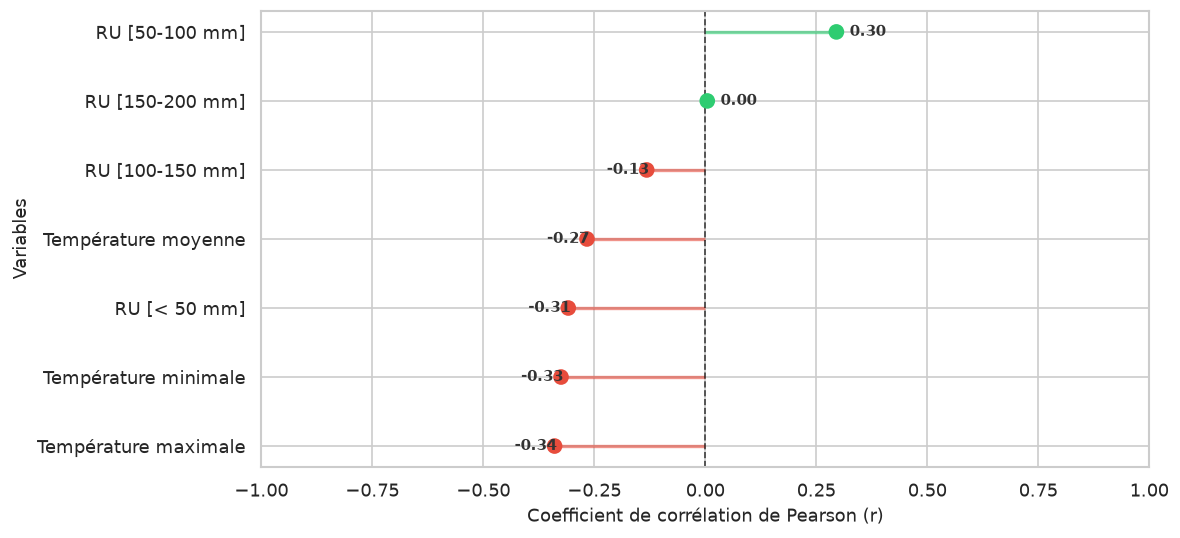

In [31]:
# Convertir la liste des résultats en DataFrame et trier par valeur de corrélation
df_corr = pd.DataFrame(correlations).sort_values(by="Corr", ascending=True)

# Configuration de la figure
plt.figure(figsize=(10, len(df_corr) * 0.35 + 1.5), dpi=120)
sns.set_theme(style="whitegrid")

# Couleurs conditionnelles : Rouge pour négatif, Vert pour positif
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in df_corr["Corr"]]

# Dessin des lignes horizontales et des points
plt.hlines(y=df_corr["Variable"], xmin=0, xmax=df_corr["Corr"], color=colors, alpha=0.6, linewidth=2)
plt.scatter(df_corr["Corr"], df_corr["Variable"], color=colors, s=70, zorder=3)

# Ligne neutre à zéro
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Formatage des titres et axes
plt.xlabel("Coefficient de corrélation de Pearson (r)", fontsize=11)
plt.ylabel("Variables", fontsize=11)
plt.xlim(-1.0, 1.0)

# Affichage des valeurs textuelles à côté des points
for idx, row in df_corr.reset_index(drop=True).iterrows():
    val = row["Corr"]
    offset = 0.03 if val >= 0 else -0.09
    plt.text(val + offset, idx, f"{val:.2f}", va='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# 9. PREDICTION SUR TOUTE LA GRILLE

In [32]:
# Sélection du modèle et du scaler
# On réutilise le meilleur fold issu de l'entraînement
model = best_fold["results"]["model"]
scaler_grid = best_fold["scaler"]

# Masquage de sécurité pour les NaNs globaux de la grille
valid_grid_mask = ~torch.isnan(X_tensor).any(dim=1)
X_grid_clean = X_tensor[valid_grid_mask]

# Normalisation (uniquement sur les variables continues)
X_grid_cont_scaled = scaler_grid.transform(
    X_grid_clean[:, :n_continuous].numpy()
)
X_grid_combined = np.concatenate(
    [X_grid_cont_scaled, X_grid_clean[:, n_continuous:].numpy()], axis=1
)
X_grid_final_tensor = torch.tensor(X_grid_combined, dtype=torch.float32)

# Inférence spatiale avec MC Dropout (100 tirages)
(mean_pred, std_pred, mean_nostress, std_nostress, mean_stress, std_stress,) = predict_with_uncertainty(
    model=model, X_tensor=X_grid_final_tensor, device=device, n_samples=100,)

# Construction des tenseurs complets avec masquage des NaNs
pred_nostress_full = torch.full(
    (len(X_tensor),), float("nan"), dtype=torch.float32
)
pred_stress_full = torch.full(
    (len(X_tensor),), float("nan"), dtype=torch.float32
)
std_nostress_full = torch.full(
    (len(X_tensor),), float("nan"), dtype=torch.float32
)
std_stress_full = torch.full(
    (len(X_tensor),), float("nan"), dtype=torch.float32
)

pred_nostress_full[valid_grid_mask] = mean_nostress
pred_stress_full[valid_grid_mask] = mean_stress
std_nostress_full[valid_grid_mask] = std_nostress
std_stress_full[valid_grid_mask] = std_stress

# Calcul de la probabilité combinée et de son incertitude
p1_full = pred_nostress_full.numpy()
p2_full = pred_stress_full.numpy()
s1_full = std_nostress_full.numpy()
s2_full = std_stress_full.numpy()

# Score combiné : P(non-stress) * (1 - P(stress))
score_combined_full = p1_full * (1 - p2_full)

# Formule de propagation des erreurs/variances
std_combined_full = np.sqrt(
    (1 - p2_full) ** 2 * s1_full**2 + p1_full**2 * s2_full**2
)

# Création de la DataFrame structurée pour l'export cartographique
df_carto_grid = pd.DataFrame(
    {
        "cell_id": grid_proj["id"],  # Identifiant spatial de chaque maille
        "proba": score_combined_full,  # Carte principale de la probabilité combinée [0, 1]
        "std_incertitude": std_combined_full,  # Carte de l'incertitude du modèle
        "p_nostress": p1_full,  # Score brut non-stress
        "p_stress": p2_full,  # Score brut stress
    }
)

# 10. CARTES

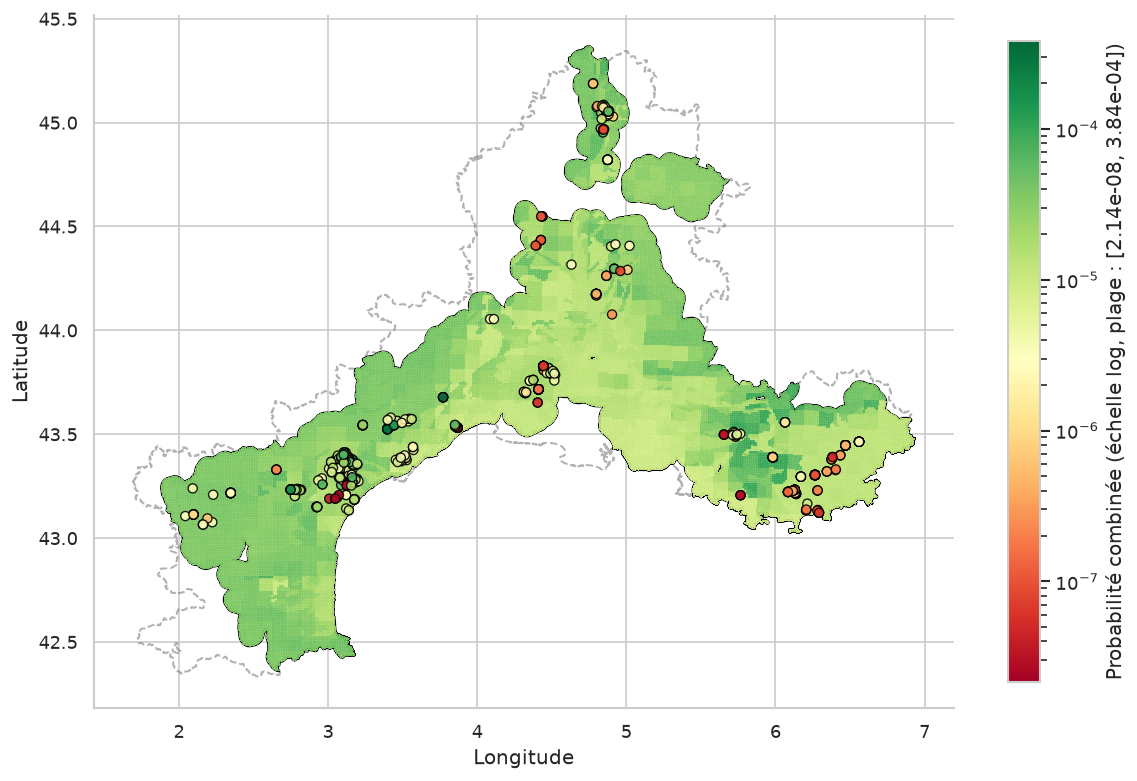

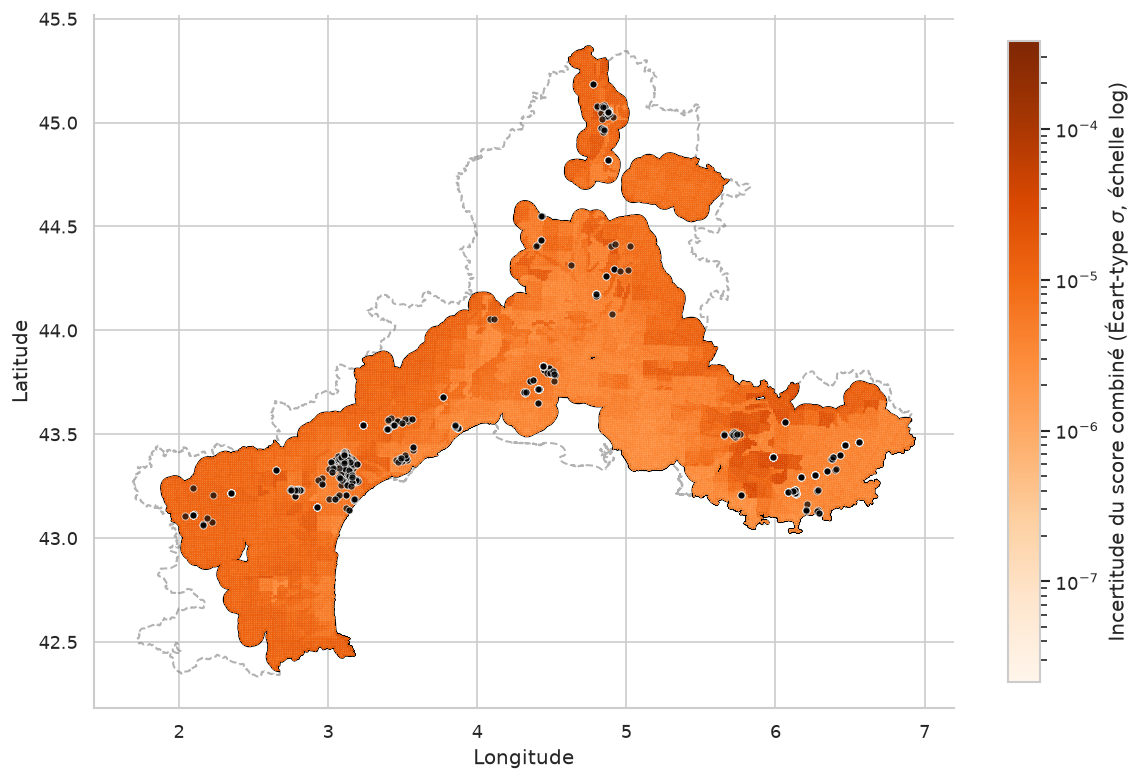

In [33]:
# Reprojection de tous les objets en 4326
grid_pred = grid_proj.to_crs("EPSG:4326").copy()

# Assignation par les valeurs NumPy pour éviter tout décalage d'index
grid_pred["proba"] = (
    score_combined_full.numpy()
    if hasattr(score_combined_full, "numpy")
    else score_combined_full
)
grid_pred["std_incertitude"] = (
    std_combined_full.numpy()
    if hasattr(std_combined_full, "numpy")
    else std_combined_full
)

study_zone_wgs = study_zone.to_crs("EPSG:4326")
study_zone_bg_wgs = study_zone_bg.to_crs("EPSG:4326")
df_zone_wgs = df_zone.to_crs("EPSG:4326").copy()

# Bornes pour l'échelle de couleurs ajustée sur l'année
with open("bornes_couleurs_reference.json") as f:
    bornes_ref = json.load(f)

bornes_tag = bornes_ref["classique"]
v_min_score = bornes_tag["v_min_score"]
v_max_score = bornes_tag["v_max_score"]

cmap_incertitude = plt.colormaps["Oranges"].copy()
cmap_incertitude.set_over("red")

# FIGURE 1 : Carte de la Probabilité Combinée

fig1, ax1 = plt.subplots(figsize=(10, 8), dpi=120)

# Fond de carte
study_zone_bg_wgs.plot(
    ax=ax1,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.2,
    linestyle="--",
    alpha=0.6,
)
study_zone_wgs.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=1.5)

# Grille de prédiction (échelle logarithmique)
grid_pred.dropna(subset=["proba"]).plot(
    ax=ax1,
    column="proba",
    cmap="RdYlGn",
    legend=True,
    alpha=0.85,
    norm=LogNorm(vmin=v_min_score, vmax=v_max_score),
    edgecolor="none",       
    antialiased=False,
    legend_kwds={
        "label": f"Probabilité combinée (échelle log, plage : [{v_min_score:.2e}, {v_max_score:.2e}])",
        "shrink": 0.7,
    },
)

# Overlay des points terrain réels
df_zone_wgs.plot(
    ax=ax1,
    column="ic_apex",
    cmap="RdYlGn",
    markersize=30,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    legend=False,
    vmin=0,
    vmax=1,
)

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# FIGURE 2 : Carte de l'Incertitude Propagée (MC-Dropout)

fig2, ax2 = plt.subplots(figsize=(10, 8), dpi=120)

study_zone_bg_wgs.plot(
    ax=ax2,
    facecolor="none",
    edgecolor="grey",
    linewidth=1.2,
    linestyle="--",
    alpha=0.6,
)
study_zone_wgs.plot(ax=ax2, facecolor="none", edgecolor="black", linewidth=1.5)

# Grille de prédiction (Incertitude, échelle logarithmique)
grid_pred.dropna(subset=["std_incertitude"]).plot(
    ax=ax2,
    column="std_incertitude",
    cmap=cmap_incertitude,
    legend=True,
    alpha=0.85,
    norm=LogNorm(vmin=v_min_score, vmax=v_max_score),
    edgecolor="none",       
    antialiased=False,      
    legend_kwds={
        "label": "Incertitude du score combiné (Écart-type $\\sigma$, échelle log)",
        "shrink": 0.7,
    },
)

df_zone_wgs.plot(
    ax=ax2,
    color="black",
    markersize=18,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.7,
    legend=False,
)

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 11. RESUME ET EXPORTS

## 11.1 Résumé tabulé : Kendall tau, AUC-ROC


In [ ]:
nb_observations = len(df_zone_wgs)
nb_cellules     = observed_mask.sum().item()
summary_rows = []
all_val_true = []

for fold_data in all_results:
    fold_idx = fold_data["fold"] - 1
    X_val_raw = x_vals[fold_idx]
    y_val_f   = y_vals[fold_idx]
    val_nan_mask = torch.isnan(X_val_raw).any(dim=1)
    X_val_clean  = X_val_raw[~val_nan_mask]
    y_val_clean  = y_val_f[~val_nan_mask]

    if len(X_val_clean) == 0:
        summary_rows.append({
            "Fold": fold_data["fold"],
            "Nb observations": nb_observations,
            "Nb cellules observées": nb_cellules,
            "Kendall tau": float("nan"),
            "AUC-ROC": float("nan")
        })
        continue

    X_val_cont_scaled = fold_data["scaler"].transform(X_val_clean[:, :n_continuous].numpy())
    X_val_tensor_f = torch.tensor(
        np.concatenate([X_val_cont_scaled, X_val_clean[:, n_continuous:].numpy()], axis=1),
        dtype=torch.float32
    )
    model_f = fold_data["results"]["model"]
    model_f.eval()
    with torch.no_grad():
        logits = model_f(X_val_tensor_f.to(device))
        val_preds = logits[:, 0].cpu().numpy()

    val_true = (y_val_clean[:, 0] / (y_val_clean[:, 0] + y_val_clean[:, 1])).numpy()
    all_val_true.append(val_true)
    tau, _ = kendalltau(val_true, val_preds)

    # Binarisation pour l'AUC-ROC et la Balanced Accuracy
    val_true_binary = (val_true >= 0.5).astype(int)

    if len(np.unique(val_true_binary)) > 1:
        auc = roc_auc_score(val_true_binary, val_preds)
    else:
        auc = float("nan")  # AUC indéfinie si une seule classe présente dans le fold

    summary_rows.append({
        "Fold": fold_data["fold"],
        "Nb observations": nb_observations,
        "Nb cellules observées": nb_cellules,
        "Kendall tau": round(tau, 4),
        "AUC-ROC": round(auc, 4) if not np.isnan(auc) else float("nan")
    })

df_summary = pd.DataFrame(summary_rows).set_index("Fold")

# Sélection des 3 meilleurs folds selon le Kendall tau (moins si pas assez disponibles)
N_BEST_FOLDS = 3
df_summary = df_summary.sort_values("Kendall tau", ascending=False, na_position="last").head(N_BEST_FOLDS)

valid_taus     = df_summary["Kendall tau"].dropna()
valid_aucs     = df_summary["AUC-ROC"].dropna()

print(f"Kendall tau moyen        : {valid_taus.mean():.4f} ± {valid_taus.std():.4f}  (sur {len(valid_taus)} folds)")
print(f"AUC-ROC moyen            : {valid_aucs.mean():.4f} ± {valid_aucs.std():.4f}  (sur {len(valid_aucs)} folds)")

df_summary

Kendall tau moyen        : 0.4147 ± 0.1010  (sur 3 folds)
AUC-ROC moyen            : 0.8112 ± 0.0332  (sur 3 folds)


,Nb observations,Nb cellules observées,Kendall tau,AUC-ROC
Fold,,,,
3,751,229,0.4920,0.8431
4,751,229,0.4517,0.8137
8,751,229,0.3004,0.7768


## 11.2 Exportation des résultats

In [ ]:
# Concatène les vraies valeurs terrain de tous les folds ; moyenne/écart-type globaux
val_true_concat = np.concatenate(all_val_true) if all_val_true else np.array([])
ic_apex_moy = float(val_true_concat.mean()) if len(val_true_concat) else float("nan")
std_ic_apex = float(val_true_concat.std())  if len(val_true_concat) else float("nan")

# Prédictions grille complète vers tableau NumPy
proba_arr = np.asarray(
    score_combined_full.numpy() if hasattr(score_combined_full, "numpy") else score_combined_full
)
std_arr = np.asarray(
    std_combined_full.numpy() if hasattr(std_combined_full, "numpy") else std_combined_full
)
# Ne garde que le positif/non-NaN
proba_pos = proba_arr[(proba_arr > 0) & ~np.isnan(proba_arr)]
std_pos = std_arr[(std_arr > 0) & ~np.isnan(std_arr)]

export_dict = {
    "date_debut_str": date_debut_str,
    "df_summary": df_summary,
    "ic_apex_moy": ic_apex_moy,
    "std_ic_apex": std_ic_apex,
    # Prédictions OOF : issues du fold de validation de chaque point
    "oof_score_combined": oof_prob_combined,
    "oof_std_combined": oof_std_combined,
    "oof_ic_apex_true": oof_ic_apex_true,
    # Extrêmes de la grille (servent au calcul des bornes de couleur globales)
    "proba_min": float(proba_pos.min()),
    "proba_max": float(proba_pos.max()),
    "proba_q99": float(np.quantile(proba_pos, 0.99)),
    "std_min": float(std_pos.min()),
    "std_max": float(std_pos.max()),
    "std_q99": float(np.quantile(std_pos, 0.99)),
}

Path("results").mkdir(exist_ok=True)
with open(f"results/{MODEL_TAG}_{date_debut_str}.pkl", "wb") as f:
    pickle.dump(export_dict, f) 

print(f"Résultats exportés : results/{MODEL_TAG}_{date_debut_str}.pkl")

✅ Résultats exportés : results/degrade_2025-07-21.pkl
